In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [1]:
import matplotlib.patches as mpatches

In [4]:
from scipy import stats

In [5]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
ts = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/ts_ssp5.nc').ts

In [7]:
pr = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/pr_ssp5.nc').pr*86400*30

In [8]:
u10 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/uas_ssp5.nc').uas
v10 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/vas_ssp5.nc').vas

In [9]:
msftbarot = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/msftbarot_ssp5.nc').msftbarot

In [10]:
ts_pi = ts.sel(time = slice('1850', '1900')).mean('time')

In [11]:
pr_pi = pr.sel(time = slice('1850', '1900')).mean('time')

In [12]:
u10_pi = u10.sel(time = slice('1850', '1900')).mean('time')
v10_pi = v10.sel(time = slice('1850', '1900')).mean('time')

In [13]:
msftbarot_pi = msftbarot.sel(time = slice('1850', '1900')).mean('time')

In [14]:
ts_eoc = ts.sel(time = slice('2050', '2100')).mean('time')

In [15]:
pr_eoc = pr.sel(time = slice('2050', '2100')).mean('time')

In [16]:
u10_eoc = u10.sel(time = slice('2050', '2100')).mean('time')
v10_eoc = v10.sel(time = slice('2050', '2100')).mean('time')

In [17]:
msftbarot_eoc = msftbarot.sel(time = slice('2050', '2100')).mean('time')

In [18]:
def kstest_1d(a, b):
    res = stats.ks_2samp(a, b)
    return res.pvalue


def kstest_3d(da1, da2, dim):
    return xr.apply_ufunc(kstest_1d, da1, da2, input_core_dims=[[dim], [dim]], vectorize=True, dask='parallelized')

In [19]:
xx, yy = np.meshgrid(ts_eoc.lon, ts_eoc.lat)

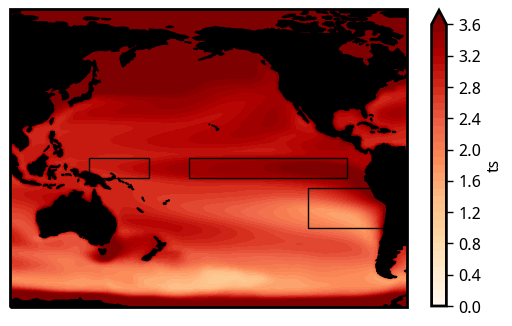

In [20]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())


pvals = kstest_3d(ts_pi, ts_eoc, dim='model')
zz = np.ma.masked_less_equal(pvals, 0.05)

(ts_eoc - ts_pi).mean('model').plot.contourf(cmap='OrRd', levels=np.arange(0,3.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8))
ax.pcolor(xx, yy, zz, hatch='///', alpha=0., transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

In [ ]:
ts

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())


pvals = kstest_3d(ts_pi, ts_eoc, dim='model')
zz = np.ma.masked_less_equal(pvals, 0.05)

(ts_eoc - ts_pi).mean('model').plot.contourf(cmap='OrRd', levels=np.arange(0,3.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8))
ax.pcolor(xx, yy, zz, hatch='///', alpha=0., transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

In [23]:
ws_pi = np.sqrt(u10_pi**2 + v10_pi**2)
ws_eoc = np.sqrt(u10_eoc**2 + v10_eoc**2)

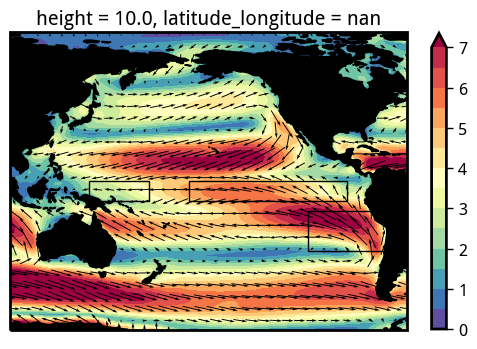

In [24]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

(ws_pi).mean('model').plot.contourf(cmap='Spectral_r', levels=np.arange(0, 7.5, 0.5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
xr.merge([u10_pi, v10_pi]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=0, vmax=7, extend='both', scale=100, robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

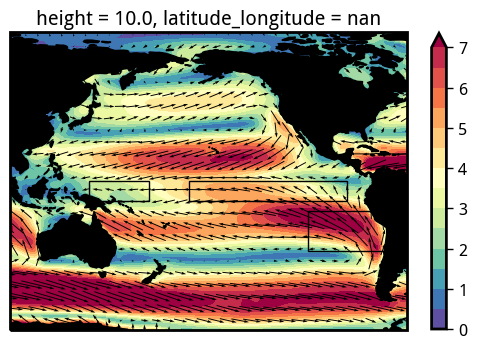

In [25]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(ws_eoc).mean('model').plot.contourf(cmap='Spectral_r', levels=np.arange(0,7.5,0.5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
xr.merge([u10_eoc, v10_eoc]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=0, vmax=7, extend='both', scale=100, robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

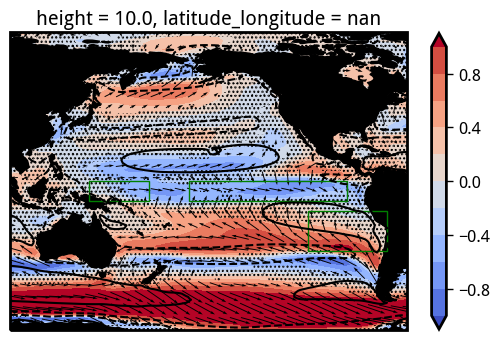

In [26]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

pvals = kstest_3d(ws_pi, ws_eoc, dim='model')
zz = np.ma.masked_less_equal(pvals, 0.05)

(ws_eoc - ws_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-1, 1.2, 0.2), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
(ws_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree(), linestyles=['--', '-'])
xr.merge([u10_eoc-u10_pi, v10_eoc-v10_pi]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=-1, vmax=1, scale=20, robust=True, transform=ccrs.PlateCarree())
ax.pcolor(xx, yy, zz, hatch='....', alpha=0., transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))


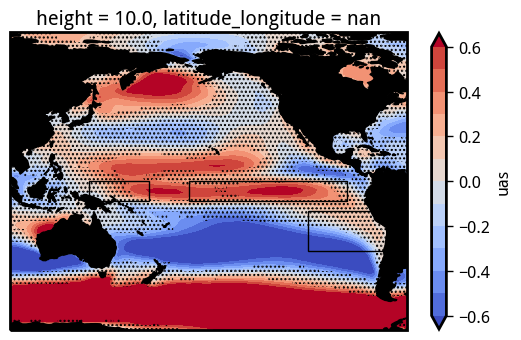

In [40]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

pvals = kstest_3d(u10_pi, u10_eoc, dim='model')
zz = np.ma.masked_less_equal(pvals, 0.05)

(u10_eoc - u10_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-0.6, 0.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
# (u10_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
ax.pcolor(xx, yy, zz, hatch='....', alpha=0., transform=ccrs.PlateCarree())
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

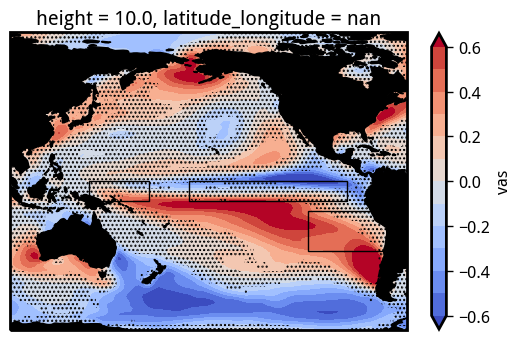

In [41]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

pvals = kstest_3d(v10_pi, v10_eoc, dim='model')
zz = np.ma.masked_less_equal(pvals, 0.05)

(v10_eoc - v10_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-0.6, 0.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
# (u10_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
ax.pcolor(xx, yy, zz, hatch='....', alpha=0., transform=ccrs.PlateCarree())
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

In [39]:
from functions import preproc_funcs as funcs

In [40]:
pr_det = funcs.detrend_dim(pr, dim='time', deg=2)

In [46]:
pr_pi_std = pr_det.sel(time = slice('1850', '1900')).std('time')

In [47]:
pr_eoc_std = pr_det.sel(time = slice('2050', '2100')).std('time')

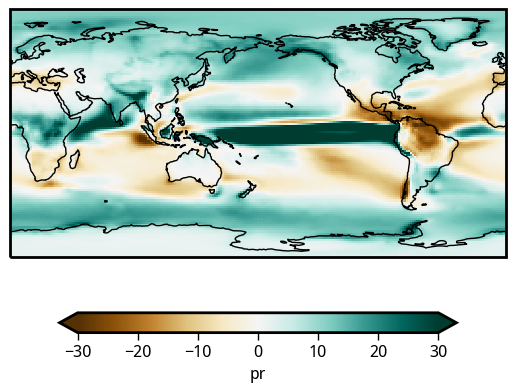

In [69]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
(pr_eoc - pr_pi).mean('model').plot(cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-30, cbar_kwargs=dict(orientation='horizontal', shrink=0.8))
ax.coastlines()

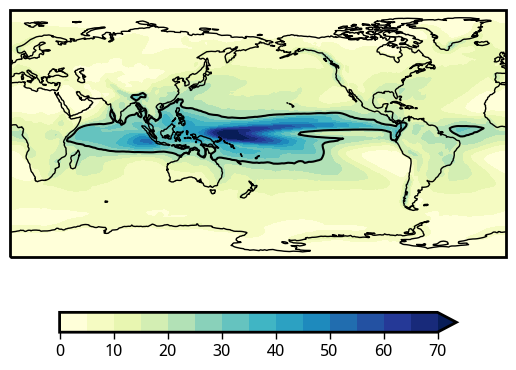

In [114]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
(pr_pi_std).mean('model').plot.contourf(cmap='YlGnBu', transform=ccrs.PlateCarree(), levels=np.arange(0, 75, 5), extend='max', cbar_kwargs=dict(orientation='horizontal', shrink=0.8), robust=True)
(pr_pi_std).mean('model').plot.contour(colors='k', transform=ccrs.PlateCarree(), levels=[25], extend='max', robust=True)
ax.coastlines()


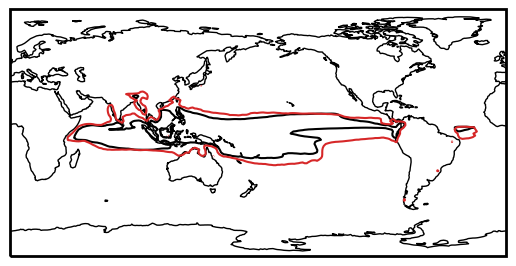

In [117]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
(pr_pi_std).mean('model').plot.contour(colors='k', transform=ccrs.PlateCarree(), levels=[29], extend='max', robust=True)
(pr_eoc_std).mean('model').plot.contour(colors='tab:red', transform=ccrs.PlateCarree(), levels=[29], extend='max', robust=True)
ax.coastlines()


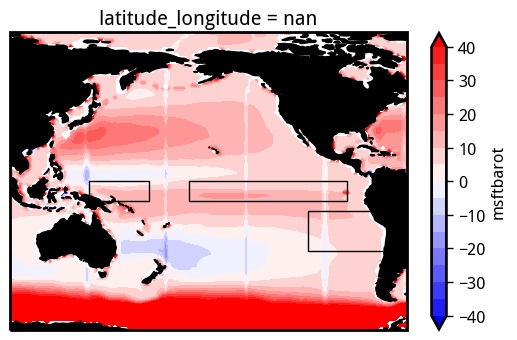

In [27]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

(msftbarot_pi/10**9).mean('model').plot.contourf(cmap='bwr', levels=np.arange(-40, 45, 5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

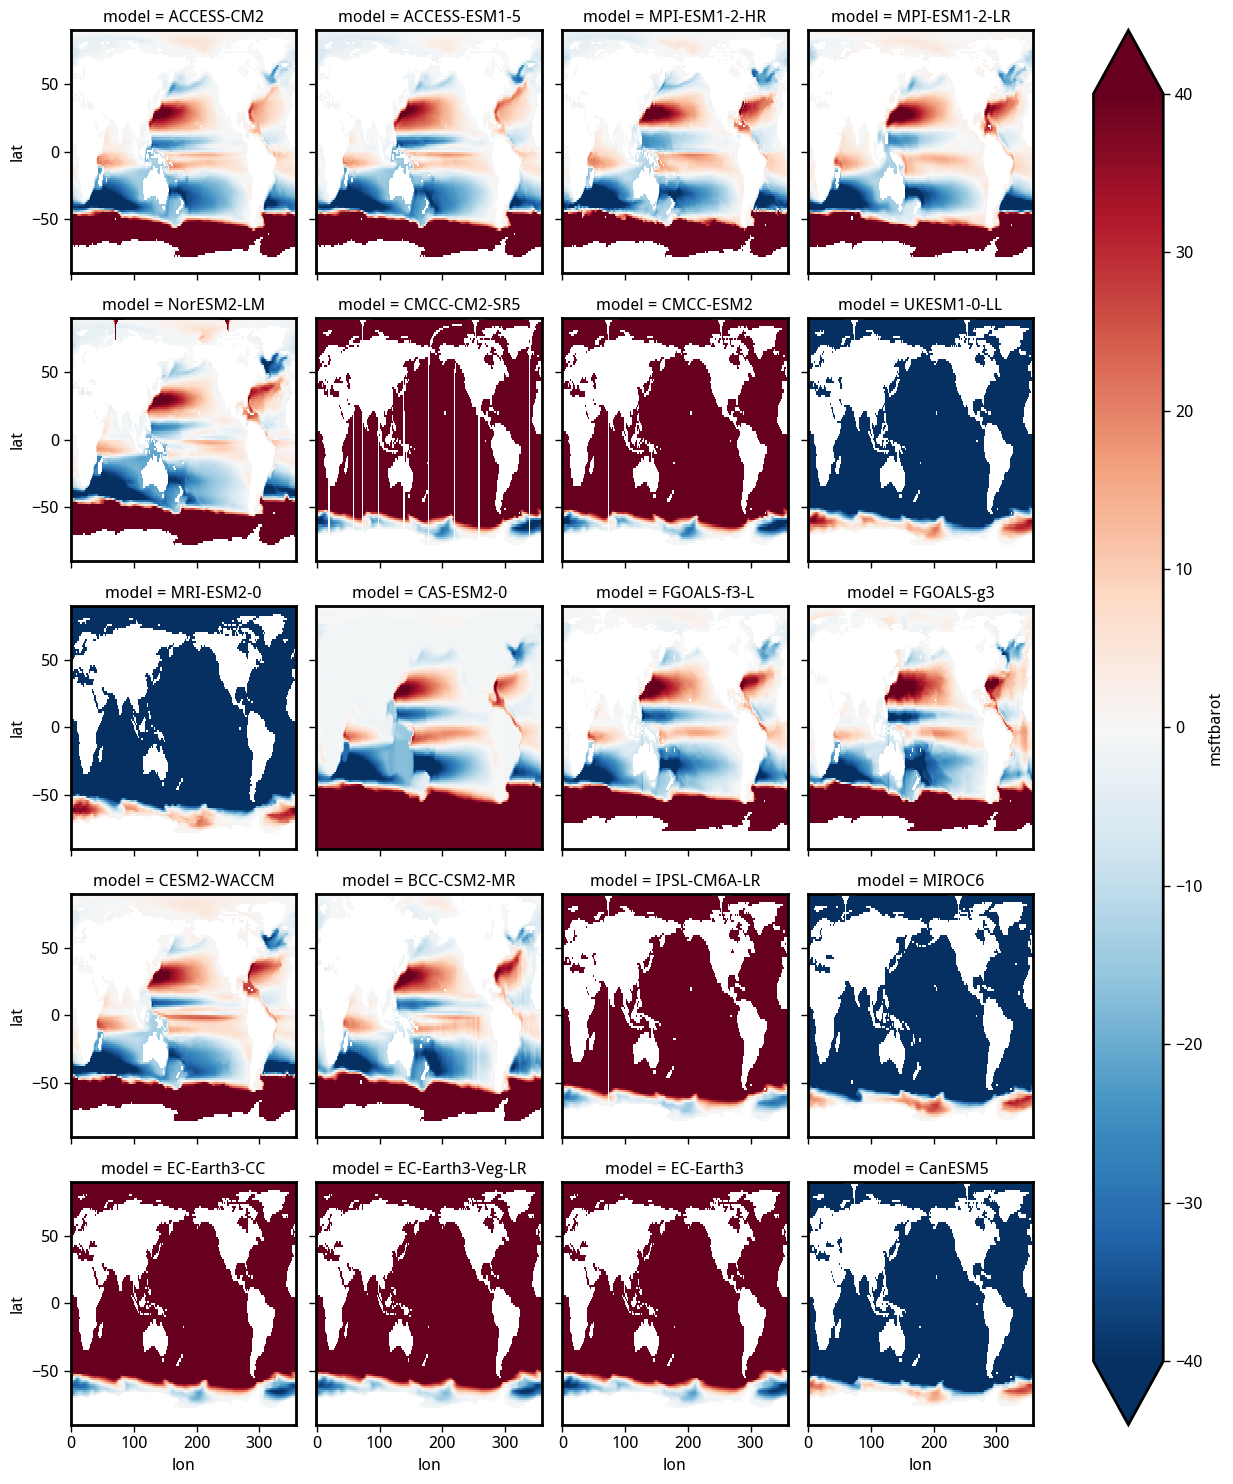

In [24]:
(msftbarot_pi/10**9).plot(vmin=-40, col='model', col_wrap=4)

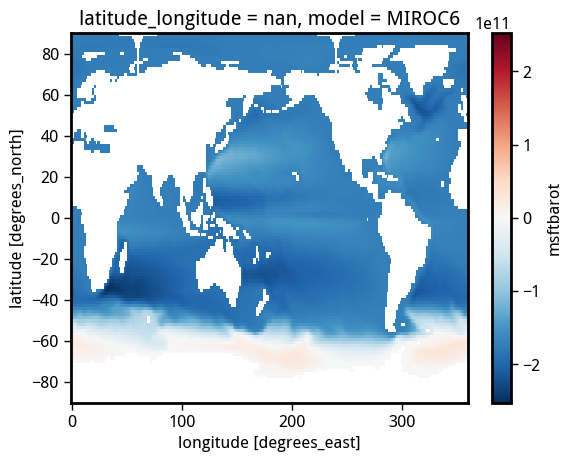

In [31]:
(msftbarot_pi.sel(model = 'MIROC6')).plot()

In [94]:
test =xc.open_mfdataset('/g/data/oi10/replicas/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/r1i1p1f1/Omon/msftbarot/gn/v20180803/msftbarot_Omon_IPSL-CM6A-LR_historical_r1i1p1f1_gn_185001-201412.nc', use_cftime=True)

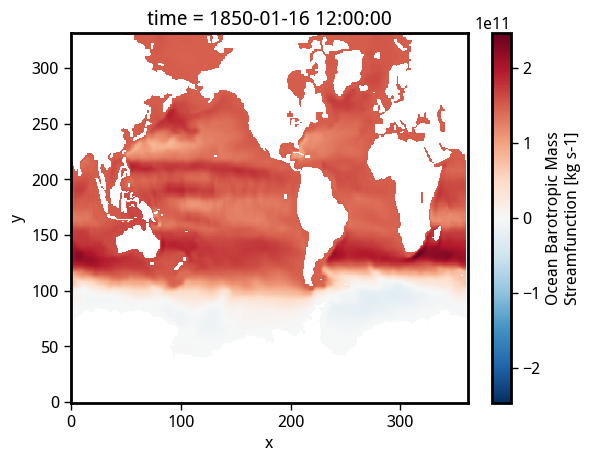

In [99]:
# ax = plt.axes(projection=ccrs.PlateCarree())
test.isel(time=0).msftbarot.plot()

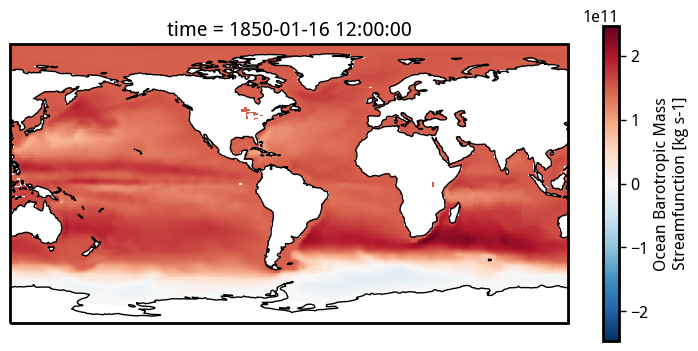

In [101]:
fig=plt.figure(figsize=(9, 9))
ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree(central_longitude=-60))
ax1.set_global()
ax1.coastlines()
test.isel(time=0).msftbarot.plot(x='nav_lon', y='nav_lat', ax=ax1, transform=ccrs.PlateCarree())
plt.show()

In [43]:
msftbarot_pi = msftbarot.drop(['CMCC-CM2-SR5', 'CMCC-ESM2', 'UKESM1-0-LL', 'MRI-ESM2-0', 'IPSL-CM6A-LR', 'MIROC6', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'EC-Earth3', 'CanESM5', 'BCC-CSM2-MR'], dim='model').sel(time = slice('1850', '1900')).mean('time')
msftbarot_eoc = msftbarot.drop(['CMCC-CM2-SR5', 'CMCC-ESM2', 'UKESM1-0-LL', 'MRI-ESM2-0', 'IPSL-CM6A-LR', 'MIROC6', 'EC-Earth3-CC', 'EC-Earth3-Veg-LR', 'EC-Earth3', 'CanESM5', 'BCC-CSM2-MR'], dim='model').sel(time = slice('2050', '2100')).mean('time')

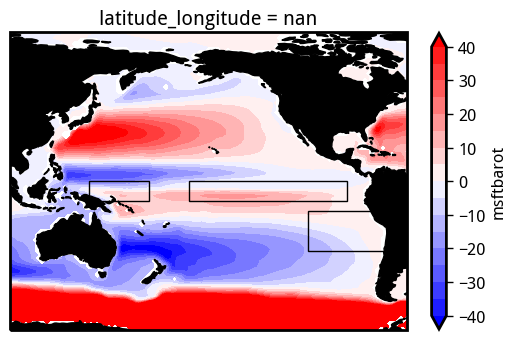

In [44]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

(msftbarot_pi/10**9).mean('model').plot.contourf(cmap='bwr', levels=np.arange(-40, 45, 5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

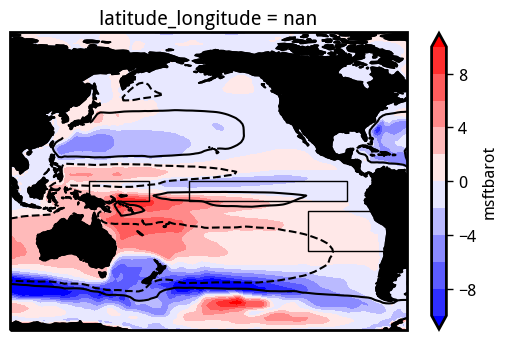

In [52]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())

# pvals = kstest_3d(msftbarot_pi, msftbarot_eoc, dim='model')
# zz = np.ma.masked_less_equal(pvals, 0.05)

((msftbarot_eoc - msftbarot_pi)/10**9).mean('model').plot.contourf(cmap='bwr', levels=np.arange(-10, 12, 2), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
ax.add_feature(cfeature.LAND, color='k', zorder=1)
(msftbarot_pi/10**9).mean('model').plot.contour(colors='k', levels=[-10, 10], transform=ccrs.PlateCarree(), robust=True)
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.pcolor(xx, yy, zz, hatch='....', alpha=0., transform=ccrs.PlateCarree())

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

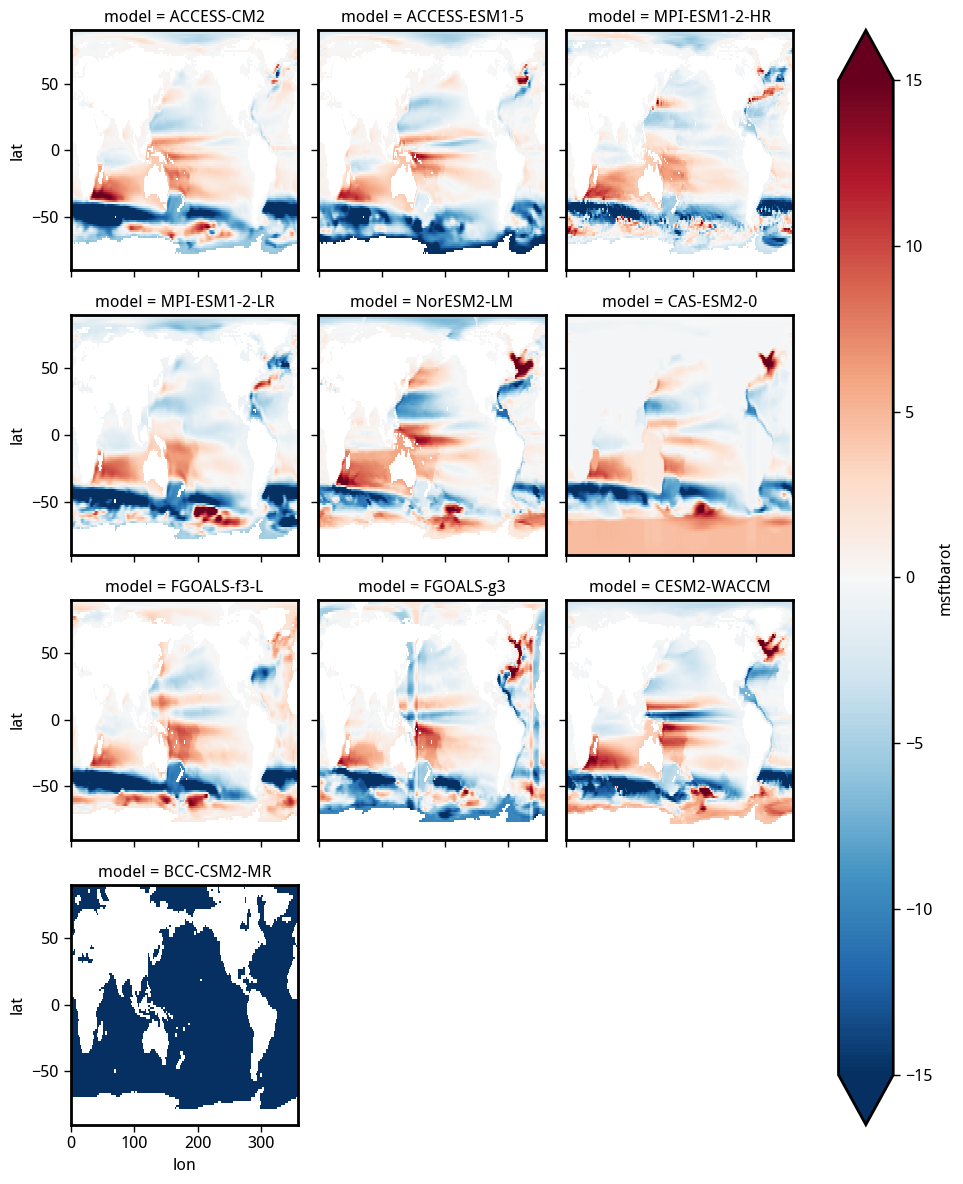

In [42]:
((msftbarot_eoc - msftbarot_pi)/10**9).plot(vmin=-15, col='model', col_wrap=3)